# Data augmentation with real datasets

This example augments real M4 time series with `SynAugment` and shows what the augmentation actually guarantees.

`SynAugment` fits a generator to each input series, draws new series from it, and then rescales every synthetic draw to the source series' **mean**, **standard deviation**, and **lag-1 autocorrelation**. Those three statistics therefore match *by construction* — reporting them back as "close to the original" would only measure the rescaling step, not the quality of the augmentation.

So instead of a fidelity table dominated by matched-by-design statistics, this page reports two things the rescaling does not determine:

1. **Whether the synthetic series are new draws rather than near-copies.** We check the correlation between each synthetic series and its source.
2. **How the unpinned properties behave** — the distribution shape (min, max, skewness), which is free to vary and shows how much the synthetic draws explore around the target moments.

**Requires**: `datasetsforecast` (`pip install datasetsforecast`)

In [ ]:
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from datasetsforecast.m4 import M4

from synforecast import SynAugment

In [ ]:
def compute_series_stats(values: np.ndarray) -> dict:
    """Compute statistical properties of a time series."""
    return {
        "mean": float(np.mean(values)),
        "std": float(np.std(values)),
        "min": float(np.min(values)),
        "max": float(np.max(values)),
        "range": float(np.max(values) - np.min(values)),
        "cv": float(np.std(values) / np.mean(values)) if np.mean(values) != 0 else 0,
        "skewness": float(np.mean(((values - np.mean(values)) / np.std(values)) ** 3))
        if np.std(values) > 0
        else 0,
        "autocorr_lag1": float(np.corrcoef(values[:-1], values[1:])[0, 1])
        if len(values) > 1
        else 0,
    }


# Statistics SynAugment matches to the source series by construction (via the
# rescaling step in SynAugment._match_autocorrelation). A small difference here
# is expected and is not evidence of augmentation quality.
PINNED_STATS = {"mean", "std", "cv", "autocorr_lag1"}


def print_comparison_table(original_stats: dict, synthetic_stats_list: list) -> None:
    """Print a comparison table of original vs synthetic statistics.

    The ``source`` column marks whether a statistic is pinned by construction or
    free to vary. Read the *free* rows to judge how much the synthetic series
    depart from the source in ways the rescaling does not control.
    """
    avg_synthetic = {}
    for key in original_stats:
        avg_synthetic[key] = np.mean([s[key] for s in synthetic_stats_list])

    header = (
        f"{'Statistic':<15} {'Original':>12} {'Synthetic (avg)':>15} "
        f"{'Diff %':>10}   {'Source':<8}"
    )
    print(header)
    print("-" * len(header))
    for key in original_stats:
        orig = original_stats[key]
        synth = avg_synthetic[key]
        if abs(orig) > 1e-6:
            diff_pct = abs(synth - orig) / abs(orig) * 100
        else:
            diff_pct = 0 if abs(synth) < 1e-6 else 100
        source = "pinned" if key in PINNED_STATS else "free"
        print(
            f"{key:<15} {orig:>12.4f} {synth:>15.4f} {diff_pct:>9.1f}%   {source:<8}"
        )


def correlation_to_source(original: np.ndarray, synthetic: np.ndarray) -> float:
    """Pearson correlation between a source series and one synthetic draw.

    A value near 1.0 would mean the synthetic series is essentially a copy;
    values near 0 mean it is an independent draw that only shares the pinned
    summary statistics.
    """
    n = min(len(original), len(synthetic))
    o, s = original[:n], synthetic[:n]
    mask = ~(np.isnan(o) | np.isnan(s))
    if mask.sum() < 2:
        return float("nan")
    return float(np.corrcoef(o[mask], s[mask])[0, 1])

## M4 hourly data

Load hourly time series from the M4 competition and analyze their patterns before augmenting.

In [ ]:
tmpdir = tempfile.mkdtemp()

df_hourly, *_ = M4.load(directory=tmpdir, group="Hourly")
df_hourly = pl.from_pandas(df_hourly)
sample_ids = df_hourly["unique_id"].unique().head(5).to_list()
df_sample = df_hourly.filter(pl.col("unique_id").is_in(sample_ids))

print(f"Loaded {df_hourly['unique_id'].n_unique()} hourly series from M4")
print(f"Using {len(sample_ids)} series for demonstration: {sample_ids}")
print(f"Total rows in sample: {len(df_sample)}")

print("\nSample data (first series, first 5 rows):")
df_sample.filter(pl.col("unique_id") == sample_ids[0]).head(5)

  0%|          | 0.00/555k [00:00<?, ?iB/s]

2.35MiB [00:00, 58.6MiB/s]                 


INFO:datasetsforecast.utils:Successfully downloaded Hourly-train.csv, 2347115, bytes.


  0%|          | 0.00/36.8k [00:00<?, ?iB/s]

133kiB [00:00, 16.4MiB/s]                   

...

100%|██████████| 3.56M/3.56M [00:00<00:00, 25.1MiB/s]


INFO:datasetsforecast.utils:Successfully downloaded submission-Naive2.zip, 3564691, bytes.


INFO:datasetsforecast.utils:Decompressing zip file...


Loaded 414 hourly series from M4
Using 5 series for demonstration: ['H81', 'H129', 'H252', 'H205', 'H147']
Total rows in sample: 4260

Sample data (first series, first 5 rows):


unique_id,ds,y
str,i64,f64
"""H81""",1,6855.0
"""H81""",2,6718.0
"""H81""",3,6441.0
"""H81""",4,5920.0
"""H81""",5,5352.0


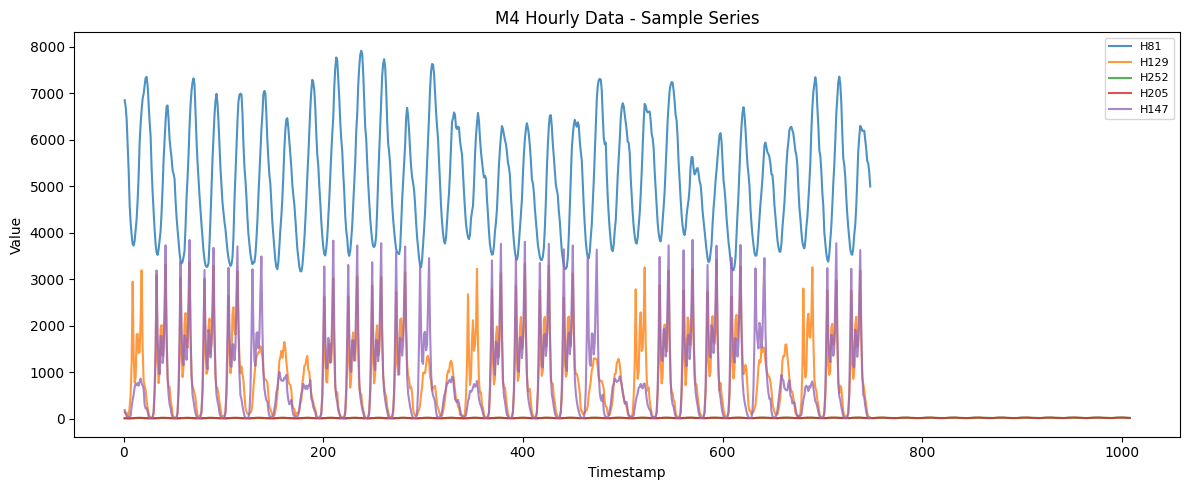

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
for uid in sample_ids:
    series = df_sample.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_title("M4 Hourly Data - Sample Series")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Analyzing series patterns

SynAugment detects seasonality, trend, and stationarity to choose the best generator for each series.

In [ ]:
augmenter = SynAugment(seed=42)

analysis = augmenter.analyze(df_sample)

for series_id in sample_ids:
    info = analysis[series_id]
    print(f"\n  {series_id}:")
    print(f"    Recommended generator: {info['recommended_generator']}")
    props = info["properties"]
    print(f"    Has seasonality: {props['seasonality']['has_seasonality']}")
    if props["seasonality"]["has_seasonality"]:
        print(f"    Seasonality period: {props['seasonality']['period']}")
    print(f"    Has trend: {props['trend']['has_trend']}")
    print(f"    Is stationary: {props['stationarity']['is_stationary']}")


  H81:
    Recommended generator: SeasonalGenerator
    Has seasonality: True
    Seasonality period: 24
    Has trend: False
    Is stationary: True

  H129:
    Recommended generator: SeasonalGenerator
    Has seasonality: True
    Seasonality period: 24
    Has trend: False
    Is stationary: True

  H252:
    Recommended generator: SARIMAGenerator
    Has seasonality: True
    Seasonality period: 24
    Has trend: True
    Is stationary: False

  H205:
    Recommended generator: SeasonalGenerator
    Has seasonality: True
    Seasonality period: 24
    Has trend: True
    Is stationary: True

  H147:
    Recommended generator: SeasonalGenerator
    Has seasonality: True
    Seasonality period: 24
    Has trend: False
    Is stationary: True


### Augmenting the data

Generate 3 synthetic series per original series.

In [ ]:
augmented_df = augmenter.augment(df_sample, n_augment=3)

print(f"Original series: {df_sample['unique_id'].n_unique()}")
print(f"Total series after augmentation: {augmented_df['unique_id'].n_unique()}")

Original series: 5
Total series after augmentation: 20


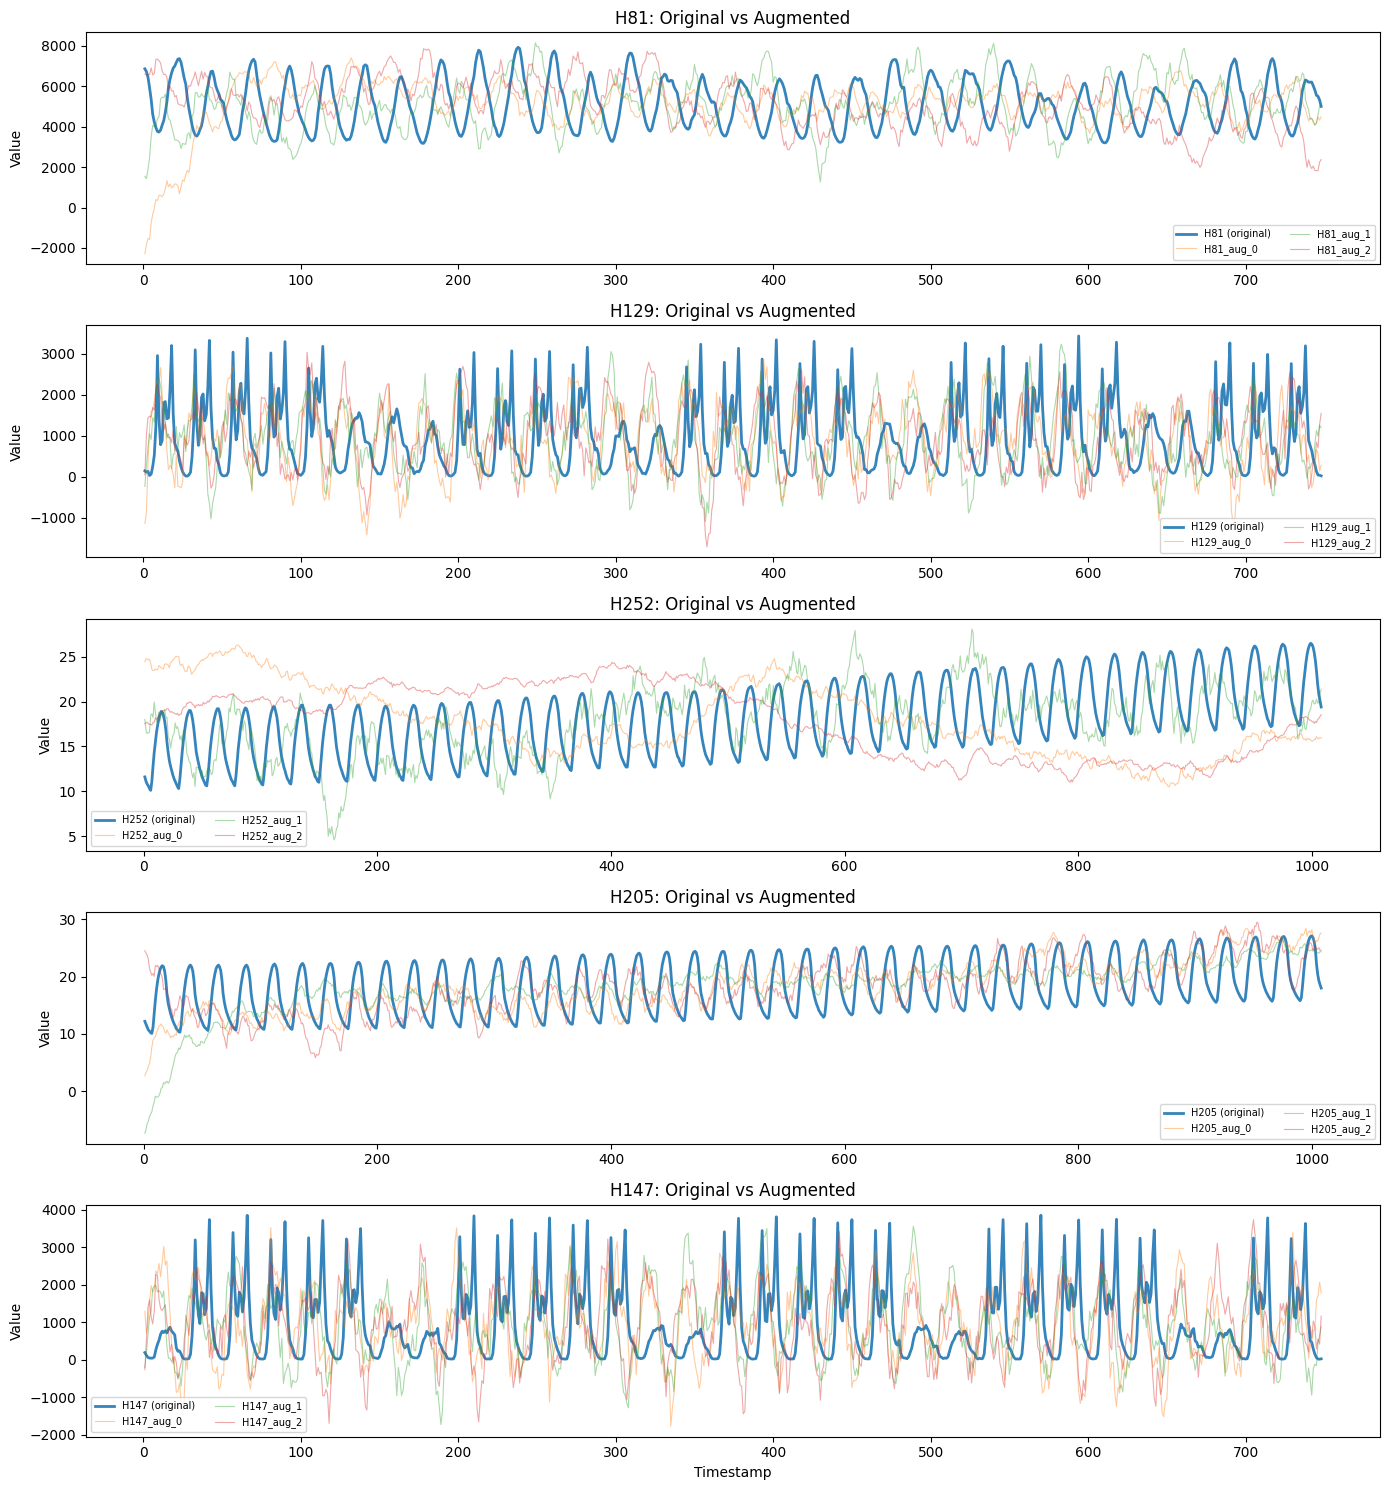

In [ ]:
fig, axes = plt.subplots(len(sample_ids), 1, figsize=(14, 3 * len(sample_ids)))
for i, uid in enumerate(sample_ids):
    ax = axes[i] if len(sample_ids) > 1 else axes
    # Plot original
    orig = augmented_df.filter(pl.col("unique_id") == uid)
    ax.plot(orig["ds"].to_list(), orig["y"].to_list(), label=f"{uid} (original)", alpha=0.9, linewidth=2)
    # Plot augmented
    for j in range(3):
        aug_id = f"{uid}_aug_{j}"
        aug = augmented_df.filter(pl.col("unique_id") == aug_id)
        if len(aug) > 0:
            ax.plot(aug["ds"].to_list(), aug["y"].to_list(), label=aug_id, alpha=0.4, linewidth=0.8)
    ax.set_title(f"{uid}: Original vs Augmented")
    ax.set_ylabel("Value")
    ax.legend(fontsize=7, ncol=2)
axes[-1].set_xlabel("Timestamp") if len(sample_ids) > 1 else axes.set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

## What augmentation pins, and what it leaves free

For one series, we compare the original statistics against the average across its synthetic draws. The `mean`, `std`, `cv`, and `autocorr_lag1` rows are pinned by construction — expect them near 0% and read nothing into it. The `min`, `max`, `range`, and `skewness` rows are free to vary and show how the synthetic draws differ in shape.

We also report the correlation between each synthetic draw and the source series. Low correlations are the point here: they show the draws are genuinely new series that happen to share the pinned summary statistics, not rescaled copies of the input.

In [ ]:
test_id = sample_ids[0]
print(f"Detailed comparison for series: {test_id}\n")

original_values = (
    augmented_df.filter(pl.col("unique_id") == test_id).sort("ds")["y"].to_numpy()
)
original_stats = compute_series_stats(original_values)

synthetic_stats_list = []
correlations = []
for i in range(3):
    aug_id = f"{test_id}_aug_{i}"
    aug_values = (
        augmented_df.filter(pl.col("unique_id") == aug_id)
        .sort("ds")["y"]
        .to_numpy()
    )
    synthetic_stats_list.append(compute_series_stats(aug_values))
    correlations.append(correlation_to_source(original_values, aug_values))

print_comparison_table(original_stats, synthetic_stats_list)
print(
    "\nCorrelation of each synthetic draw to the source series: "
    + ", ".join(f"{c:.2f}" for c in correlations)
)
print(
    "Low correlations confirm the synthetic series are independent draws that "
    "share the pinned statistics, not copies of the input."
)

Detailed comparison for series: H81

Statistic           Original Synthetic (avg)     Diff %   Source  
------------------------------------------------------------------
mean               5117.0949       5117.1168       0.0%   pinned  
std                1203.9642       1203.9868       0.0%   pinned  
min                3172.0000        264.2059      91.7%   free    
max                7920.0000       7793.0231       1.6%   free    
range              4748.0000       7528.8171      58.6%   free    
cv                    0.2353          0.2353       0.0%   pinned  
skewness              0.2127         -0.9023     524.3%   free    
autocorr_lag1         0.9628          0.9670       0.4%   pinned  

Correlation of each synthetic draw to the source series: -0.31, -0.37, -0.32
Low correlations confirm the synthetic series are independent draws that share the pinned statistics, not copies of the input.


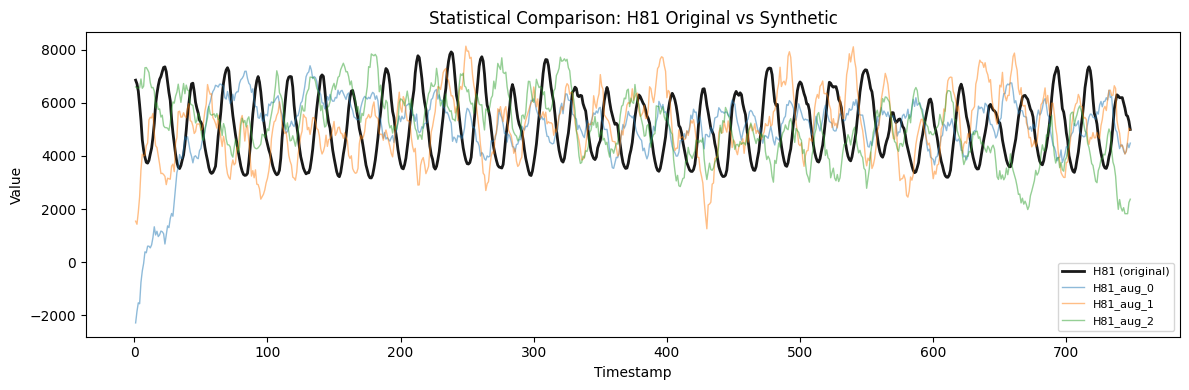

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
# Plot original series
orig = augmented_df.filter(pl.col("unique_id") == test_id)
ax.plot(orig["ds"].to_list(), orig["y"].to_list(), label=f"{test_id} (original)", alpha=0.9, linewidth=2, color="black")
# Plot synthetic copies
for i in range(3):
    aug_id = f"{test_id}_aug_{i}"
    aug = augmented_df.filter(pl.col("unique_id") == aug_id)
    if len(aug) > 0:
        ax.plot(aug["ds"].to_list(), aug["y"].to_list(), label=aug_id, alpha=0.5, linewidth=1)
ax.set_title(f"Statistical Comparison: {test_id} Original vs Synthetic")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## M4 daily data

Augment daily frequency data from the M4 competition.

In [ ]:
df_daily, *_ = M4.load(directory=tmpdir, group="Daily")
df_daily = pl.from_pandas(df_daily)

daily_ids = df_daily["unique_id"].unique().head(4).to_list()
df_daily_sample = df_daily.filter(pl.col("unique_id").is_in(daily_ids))

print(f"Loaded {df_daily['unique_id'].n_unique()} daily series from M4")
print(f"Using {len(daily_ids)} series: {daily_ids}")

augmenter_daily = SynAugment(seed=123)
analysis_daily = augmenter_daily.analyze(df_daily_sample)

print("\nAnalysis results:")
for series_id in daily_ids:
    info = analysis_daily[series_id]
    print(f"  {series_id}: {info['recommended_generator']}")

augmented_daily = augmenter_daily.augment(df_daily_sample, n_augment=2)
print(
    f"\nAugmented from {len(daily_ids)} to {augmented_daily['unique_id'].n_unique()} series"
)

  0%|          | 0.00/32.5M [00:00<?, ?iB/s]

 24%|██▎       | 7.67M/32.5M [00:00<00:00, 76.7MiB/s]

 47%|████▋     | 15.3M/32.5M [00:00<00:00, 75.6MiB/s]

 72%|███████▏  | 23.4M/32.5M [00:00<00:00, 77.9MiB/s]

 99%|█████████▊| 32.0M/32.5M [00:00<00:00, 81.0MiB/s]

...

  0%|          | 0.00/198k [00:00<?, ?iB/s]

576kiB [00:00, 30.1MiB/s]                  


INFO:datasetsforecast.utils:Successfully downloaded Daily-test.csv, 576459, bytes.


Loaded 4227 daily series from M4
Using 4 series: ['D3887', 'D785', 'D1866', 'D679']

Analysis results:
  D3887: RandomWalkGenerator
  D785: GeometricBrownianMotionGenerator
  D1866: RandomWalkGenerator
  D679: GeometricBrownianMotionGenerator



Augmented from 4 to 12 series


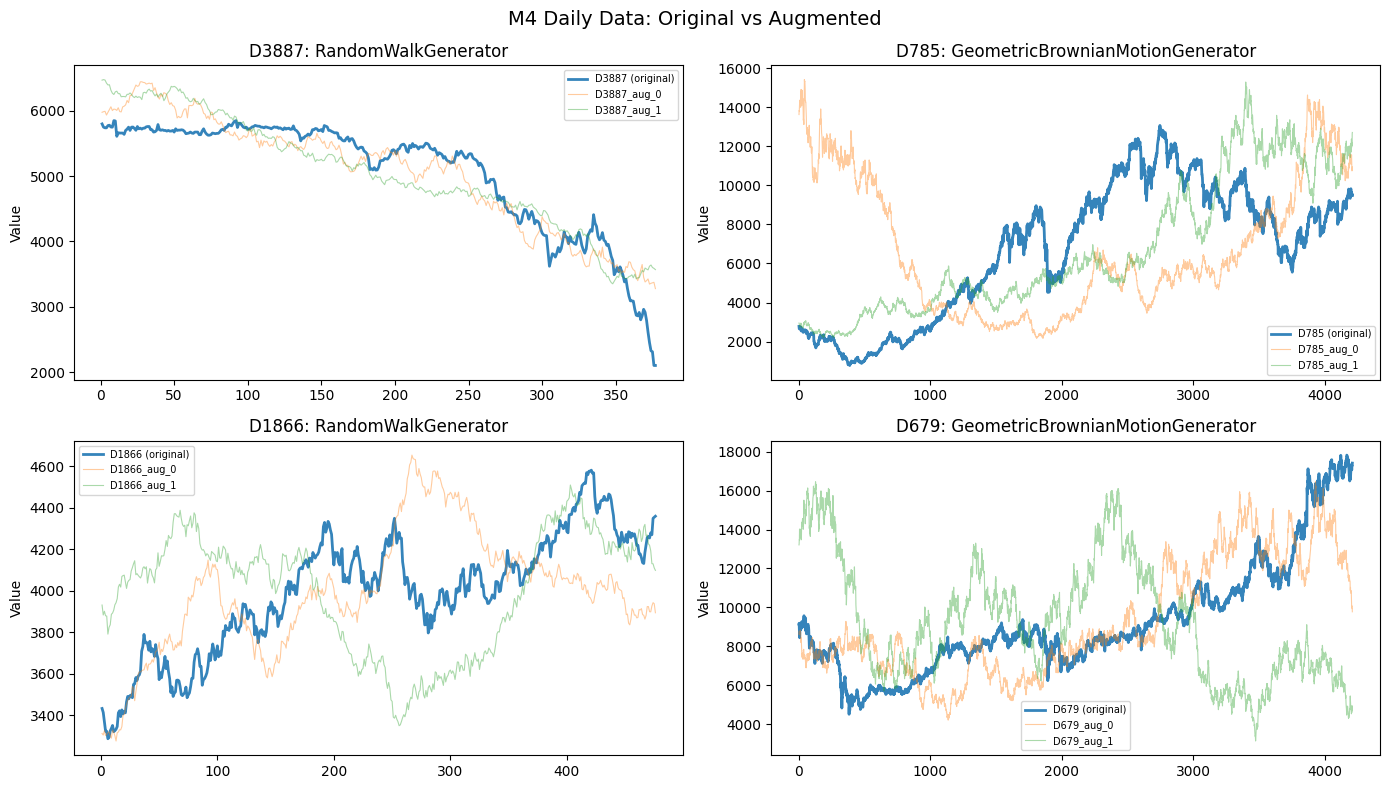

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, uid in enumerate(daily_ids):
    ax = axes[i // 2][i % 2]
    # Original
    orig = augmented_daily.filter(pl.col("unique_id") == uid)
    ax.plot(orig["ds"].to_list(), orig["y"].to_list(), label=f"{uid} (original)", alpha=0.9, linewidth=2)
    # Augmented
    for j in range(2):
        aug_id = f"{uid}_aug_{j}"
        aug = augmented_daily.filter(pl.col("unique_id") == aug_id)
        if len(aug) > 0:
            ax.plot(aug["ds"].to_list(), aug["y"].to_list(), label=aug_id, alpha=0.4, linewidth=0.8)
    ax.set_title(f"{uid}: {analysis_daily[uid]['recommended_generator']}")
    ax.set_ylabel("Value")
    ax.legend(fontsize=7)
plt.suptitle("M4 Daily Data: Original vs Augmented", fontsize=14)
plt.tight_layout()
plt.show()

## Cross-series statistics

Because every synthetic series is pinned to its source's mean and std, the panel-level averages of those statistics line up almost exactly. That confirms the pinning holds across the whole panel — it is not emergent fidelity. In the histograms the synthetic means and stds stack on the same locations as the originals (three synthetic draws per source), while the lag-1 autocorrelation, which is only *approximately* targeted, shows a little more spread.

In [ ]:
original_means = []
original_stds = []
original_autocorrs = []

for series_id in sample_ids:
    values = (
        df_sample.filter(pl.col("unique_id") == series_id)
        .sort("ds")["y"]
        .to_numpy()
    )
    original_means.append(np.mean(values))
    original_stds.append(np.std(values))
    if len(values) > 1:
        original_autocorrs.append(np.corrcoef(values[:-1], values[1:])[0, 1])

synthetic_means = []
synthetic_stds = []
synthetic_autocorrs = []

synthetic_ids = [
    uid
    for uid in augmented_df["unique_id"].unique().to_list()
    if "_aug_" in str(uid)
]

for series_id in synthetic_ids:
    values = (
        augmented_df.filter(pl.col("unique_id") == series_id)
        .sort("ds")["y"]
        .to_numpy()
    )
    synthetic_means.append(np.mean(values))
    synthetic_stds.append(np.std(values))
    if len(values) > 1:
        synthetic_autocorrs.append(np.corrcoef(values[:-1], values[1:])[0, 1])

print(f"Original series ({len(sample_ids)} series):")
print(
    f"  Mean of means: {np.mean(original_means):.4f} (std: {np.std(original_means):.4f})"
)
print(
    f"  Mean of stds:  {np.mean(original_stds):.4f} (std: {np.std(original_stds):.4f})"
)
print(
    f"  Mean autocorr: {np.mean(original_autocorrs):.4f} (std: {np.std(original_autocorrs):.4f})"
)

print(f"\nSynthetic series ({len(synthetic_ids)} series):")
print(
    f"  Mean of means: {np.mean(synthetic_means):.4f} (std: {np.std(synthetic_means):.4f})"
)
print(
    f"  Mean of stds:  {np.mean(synthetic_stds):.4f} (std: {np.std(synthetic_stds):.4f})"
)
print(
    f"  Mean autocorr: {np.mean(synthetic_autocorrs):.4f} (std: {np.std(synthetic_autocorrs):.4f})"
)

Original series (5 series):
  Mean of means: 1405.4505 (std: 1900.7867)
  Mean of stds:  595.7919 (std: 499.0039)
  Mean autocorr: 0.8816 (std: 0.1060)

Synthetic series (15 series):
  Mean of means: 1405.4619 (std: 1900.7935)
  Mean of stds:  595.7967 (std: 499.0105)
  Mean autocorr: 0.9422 (std: 0.0509)


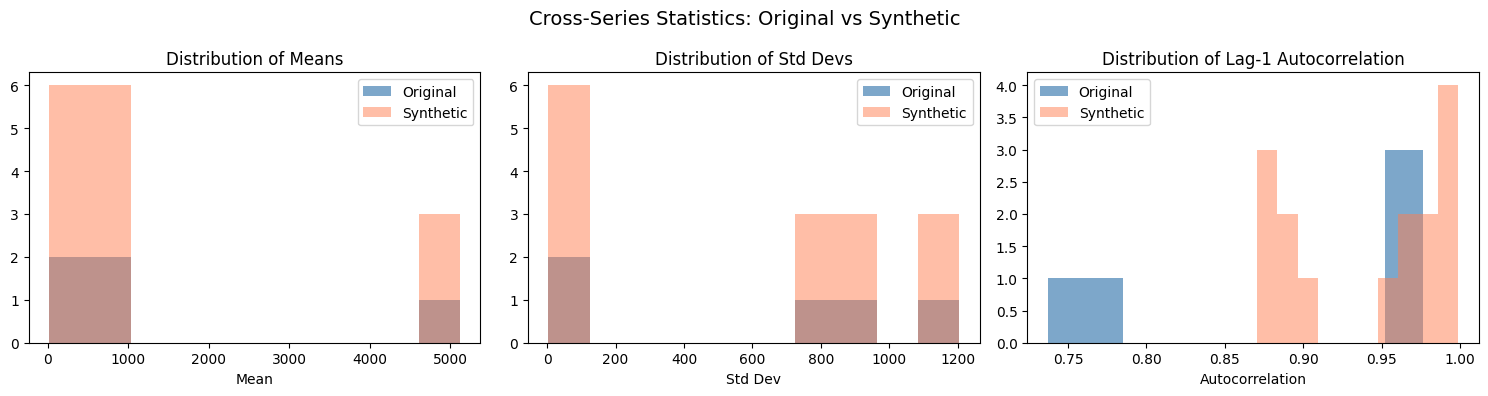

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(original_means, bins=10, alpha=0.7, label="Original", color="steelblue")
axes[0].hist(synthetic_means, bins=10, alpha=0.5, label="Synthetic", color="coral")
axes[0].set_title("Distribution of Means")
axes[0].set_xlabel("Mean")
axes[0].legend()

axes[1].hist(original_stds, bins=10, alpha=0.7, label="Original", color="steelblue")
axes[1].hist(synthetic_stds, bins=10, alpha=0.5, label="Synthetic", color="coral")
axes[1].set_title("Distribution of Std Devs")
axes[1].set_xlabel("Std Dev")
axes[1].legend()

axes[2].hist(original_autocorrs, bins=10, alpha=0.7, label="Original", color="steelblue")
axes[2].hist(synthetic_autocorrs, bins=10, alpha=0.5, label="Synthetic", color="coral")
axes[2].set_title("Distribution of Lag-1 Autocorrelation")
axes[2].set_xlabel("Autocorrelation")
axes[2].legend()

plt.suptitle("Cross-Series Statistics: Original vs Synthetic", fontsize=14)
plt.tight_layout()
plt.show()

## Augmenting for ML training

A common use case: expand a small dataset to create a larger training set for ML models.

In [ ]:
small_dataset = df_hourly.filter(
    pl.col("unique_id").is_in(df_hourly["unique_id"].unique().head(10).to_list())
)

print(f"Original training set: {small_dataset['unique_id'].n_unique()} series")
print(f"Total observations: {len(small_dataset)}")

ml_augmenter = SynAugment(seed=42)
expanded_dataset = ml_augmenter.augment(small_dataset, n_augment=5)

print(f"\nExpanded training set: {expanded_dataset['unique_id'].n_unique()} series")
print(f"Total observations: {len(expanded_dataset)}")
print(f"Expansion factor: {len(expanded_dataset) / len(small_dataset):.1f}x")

lengths = expanded_dataset.group_by("unique_id").agg(pl.len().alias("length"))
print(f"\nSeries length distribution:")
print(f"  Min: {lengths['length'].min()}, Max: {lengths['length'].max()}")
print(f"  Mean: {lengths['length'].mean():.1f}")

Original training set: 10 series
Total observations: 9040



Expanded training set: 60 series
Total observations: 54240
Expansion factor: 6.0x

Series length distribution:
  Min: 748, Max: 1008
  Mean: 904.0


## A non-duplication check

Before using an augmented panel, a basic sanity check is whether its synthetic draws are near-copies of the source series. `SynAugment` pins each synthetic series to its source's summary statistics but draws the series fresh. The check below measures non-duplication only; it is not a privacy test.

To check, we z-normalize every series (dropping the pinned mean and std so we compare shape, not level) and measure how far each synthetic series is from its nearest real series. The distances between the real series themselves give the reference scale.

closest pair of REAL series:          z-distance 0.26
every synthetic to its NEAREST real:  z-distance >= 0.94
synthetic closer to a real than the closest real-real pair: 0 / 15


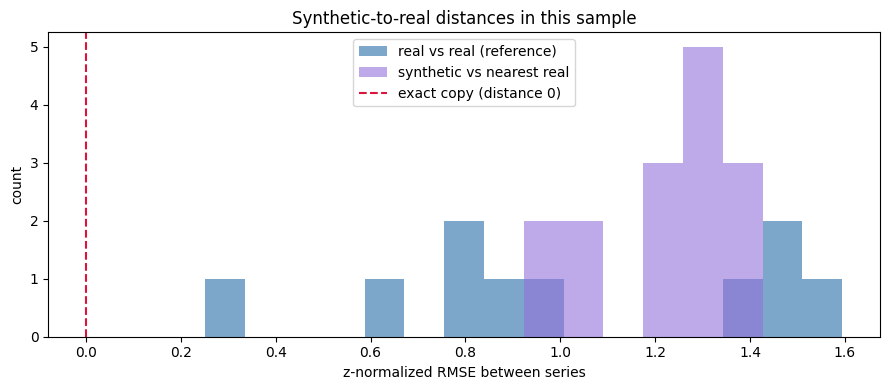

In [ ]:
import itertools


def _znorm(a):
    return (a - np.mean(a)) / (np.std(a) + 1e-9)


privacy_real = {
    u: df_sample.filter(pl.col('unique_id') == u).sort('ds')['y'].to_numpy()
    for u in sample_ids
}
_L = min(len(v) for v in privacy_real.values())
_R = {u: _znorm(v[:_L]) for u, v in privacy_real.items()}


def _zdist(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))


real_real = np.array([_zdist(_R[a], _R[b]) for a, b in itertools.combinations(_R, 2)])
syn_ids_priv = [u for u in augmented_df['unique_id'].unique().to_list() if '_aug_' in u]
syn_nn = np.array([
    min(_zdist(_znorm(augmented_df.filter(pl.col('unique_id') == sid)
               .sort('ds')['y'].to_numpy()[:_L]), _R[u]) for u in _R)
    for sid in syn_ids_priv
])

print(f'closest pair of REAL series:          z-distance {real_real.min():.2f}')
print(f'every synthetic to its NEAREST real:  z-distance >= {syn_nn.min():.2f}')
print(f'synthetic closer to a real than the closest real-real pair: '
      f'{int((syn_nn < real_real.min()).sum())} / {len(syn_nn)}')

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, max(real_real.max(), syn_nn.max()) * 1.05, 20)
ax.hist(real_real, bins=bins, alpha=0.7, color='steelblue',
        label='real vs real (reference)')
ax.hist(syn_nn, bins=bins, alpha=0.6, color='mediumpurple',
        label='synthetic vs nearest real')
ax.axvline(0.0, color='crimson', ls='--', label='exact copy (distance 0)')
ax.set(xlabel='z-normalized RMSE between series', ylabel='count',
       title='Synthetic-to-real distances in this sample')
ax.legend()
plt.tight_layout()
plt.show()

In this sample, every synthetic series sits farther from its nearest real series than the closest pair of real series sit from each other, and none lands near the zero-distance mark an exact copy would. This rules out exact and near duplicates under this one distance metric; it does not test resistance to reconstruction or inference attacks.

:::{.callout-warning}
## What this is, and is not

This is only an empirical non-duplication check under z-normalized RMSE. It does not establish resistance to reconstruction, membership inference, attribute inference, or other privacy attacks. `SynAugment` provides no differential-privacy guarantee or epsilon bound. For sensitive or regulated data, use a dedicated disclosure-risk assessment and appropriate privacy controls.
:::

## Summary

- `SynAugment` guarantees the mean, standard deviation, and lag-1 autocorrelation of each synthetic series by rescaling it to its source. Treat those matches as a property of the method, not as a validation result.
- The synthetic series are new draws rather than copies: their trajectories decorrelate from the source, and their distribution shape (min, max, skewness) varies freely around the pinned moments.
- Use augmentation to expand a small panel with series that share the summary statistics of the originals. Fit augmentation parameters on the training split only, and choose the augmentation ratio on validation data — never on the final holdout.
- Before sharing, run non-duplication and domain-specific disclosure-risk checks. This example's distance test is a sanity check, not evidence of privacy.